## Initialization

In [1]:
import importlib

In [2]:
import tex # comment this if Python on your system is not "linked" with TeX.
import func_analysis
import func_input

pathstartswith = '/Users/lakshgupta/Downloads/Personal/P-NGC2808WD/'
clusternames = ['2808', '0104'] # change this to run for other clusters.

import theoreticalmodels
importlib.reload(theoreticalmodels)
import namingroutine
importlib.reload(namingroutine)
import inputdata
importlib.reload(inputdata)
import clusterparams
importlib.reload(clusterparams)

# following must be loaded as they are used ahead. 
# I have commented the how to use, for example, 'colors' list from namingroutine.py.

models = theoreticalmodels.Initialize(func_input.ReadingModels, pathstartswith)
names = namingroutine.Initialize()
dfparams = clusterparams.Initialize()
dfclusters_input = inputdata.Initialize(func_input.LoadClusters, pathstartswith, clusternames)

dfclusters = dict(sorted(dfclusters_input['dfclusters'].items()))

<Figure size 585.25x413.875 with 0 Axes>

In [3]:
# print(models['iso131'])
# print(names['colors'])
# print(dfclusters['ngc2808'])

# dfparams['dfparams'].to_csv('cluster_param.csv', index=False) # to save the cluster parameters in a csv file.

## Spatial Plot

Spatial plot of all entered clusters being printed.


<Figure size 585.25x413.875 with 0 Axes>

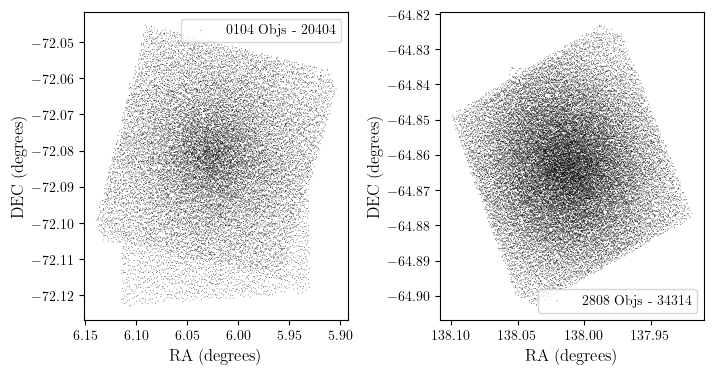

CMD of all 2 being printed:


<Figure size 585.25x413.875 with 0 Axes>

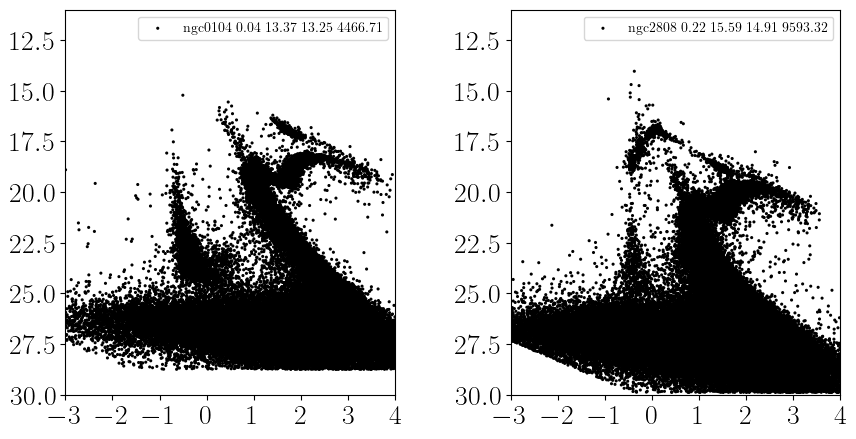

In [ ]:
clusterlist = {
    'ngc2808': dfclusters['ngc2808'],
    'ngc0104': dfclusters['ngc0104']
}

import spatialplot
importlib.reload(spatialplot)
import plotcmd
importlib.reload(plotcmd)

spatialplot.allclusters(dfclusters, dpi=100, legend=True, afterhowmany=10) # 'afterhowmany' is the after how many rows shall the code pick the next row to print - aim is to reduce computational time.
plotcmd.allclusters(func_analysis.cleandata, dfparams, names['dictfilters'], dfclusters, dpi=100, pmholder=[-12], legend=True)

## Pre-analysis checks on models

In [5]:
for i in range(len(clusternames)):
    clustername = 'ngc' + clusternames[i]
    print("For " + clustername + " values are:")
    racluster = round(dfparams['dfparams'].loc[dfparams['dfparams']['ID'] == clustername, "RA"].values[0], 4)
    deccluster = round(dfparams['dfparams'].loc[dfparams['dfparams']['ID'] == clustername, "DEC"].values[0], 4)
    metallicity = round(dfparams['dfparams'].loc[dfparams['dfparams']['ID'] == clustername, "[Fe/H]"].values[0], 3)
    reddening = round(dfparams['dfparams'].loc[dfparams['dfparams']['ID'] == clustername, "E(B-V)"].values[0], 3)
    DM = dfparams['dfparams'].loc[dfparams['dfparams']['ID'] == clustername, "(m-M)V"].values[0]
    aDM = round(DM - 3.1*reddening, 2)
    d = round(10 * (10 ** ((aDM) / 5)) - (3.1 * (reddening)), 2)

    print("Parameters of " + clustername + " from Harris Catalogue:")
    print("RA and DEC: " + str(racluster) + " " + str(deccluster))
    print("Metallicity: " + str(metallicity)) # use this metallicity value to dowload models
    print("Reddening: " + str(reddening))
    print("Absolute Distance Modulus: " + str(DM))
    print("Apparent Distance Modulus: " + str(aDM))
    print("Distance in pc: " + str(d))
    print("-------------------------------")

For ngc2808 values are:
Parameters of ngc2808 from Harris Catalogue:
RA and DEC: 138.0129 -64.8635
Metallicity: -1.14
Reddening: 0.22
Absolute Distance Modulus: 15.59
Apparent Distance Modulus: 14.91
Distance in pc: 9593.32
-------------------------------
For ngc0104 values are:
Parameters of ngc0104 from Harris Catalogue:
RA and DEC: 6.0236 -72.0813
Metallicity: -0.72
Reddening: 0.04
Absolute Distance Modulus: 13.37
Apparent Distance Modulus: 13.25
Distance in pc: 4466.71
-------------------------------


<Figure size 585.25x413.875 with 0 Axes>

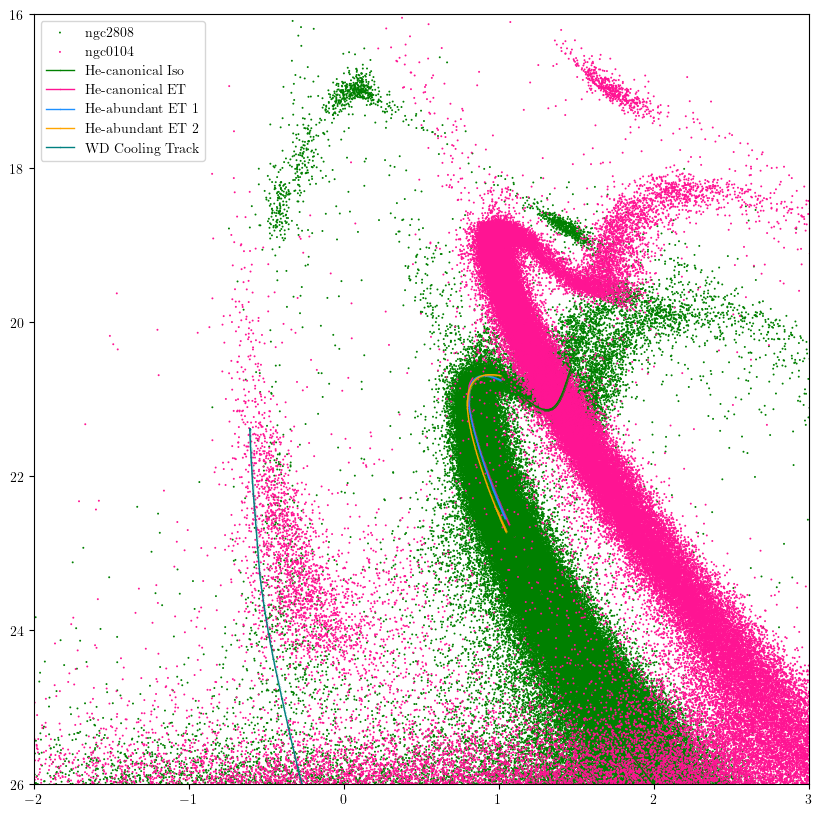

In [9]:
clustername = 'ngc2808'
metallicity = round(dfparams['dfparams'].loc[dfparams['dfparams']['ID'] == clustername, "[Fe/H]"].values[0], 3)
reddening = round(dfparams['dfparams'].loc[dfparams['dfparams']['ID'] == clustername, "E(B-V)"].values[0], 3)
DM = dfparams['dfparams'].loc[dfparams['dfparams']['ID'] == clustername, "(m-M)V"].values[0]
aDM = round(DM - 3.1*reddening, 2)
d = round(10 * (10 ** ((aDM) / 5)) - (3.1 * (reddening)), 2)

ageiso = 12000
c_masset = 80
a_masset1 = 70
a_masset2 = 60
wdmass = '054'

# The following models are input for the msto.py and wd.py directly. 
# Please check before calling the MSTO and WD routines. 
# One can skip abundantet1 and abundantet2 by putting wantabund=False.
# 1 Isochrone and 1 ET is essential to run the MSTO routine. 
# 1 WD Model is essential to run the WD routine.

# the apparent distance modulus and reddening value used can be adjusted. 
# I have done this below as adding some value to aDM and reddening.
# One can also artifically redden or de-redden the models. This is done by adding or subtracting some value from 'F336W' filter.

c_isohold = models['iso131'][str(ageiso)]
canonicaliso_dict = func_analysis.corrections(aDM+0.01, reddening-0.005, {'main': c_isohold[0:600]})
canonicaliso = canonicaliso_dict['main']  
canonicaliso['F336W'] -= 0.1
# print(canonicaliso)

c_ethold = models['et131_c'][str(c_masset)]
canonicalet_dict = func_analysis.corrections(aDM+0.01, reddening-0.030, {'main': c_ethold[0:300]})
canonicalet = canonicalet_dict['main']
canonicalet['F336W'] -= 0.1

a_et1hold = models['et131_a1'][str(a_masset1)]
abundantet1_dict = func_analysis.corrections(aDM-0.15, reddening-0.025, {'main': a_et1hold[100:350]})
abundantet1 = abundantet1_dict['main']
abundantet1['F336W'] -= 0.1

a_et2hold = models['et131_a2'][str(a_masset2)]
abundantet2_dict = func_analysis.corrections(aDM-0.11, reddening, {'main': a_et2hold[100:350]})
abundantet2 = abundantet2_dict['main']
abundantet2['F336W'] -= 0.17

wd_hold = models['wdCOHZ0420'][wdmass]
wdcooling_dict = func_analysis.corrections(aDM-0.01, reddening, {'main': wd_hold})
wdcooling = wdcooling_dict['main'] 
wdcooling['F336W'] -= 0.0  

import matplotlib.pyplot as plt

dictholdmodels_ms = {'He-canonical Iso': canonicaliso, 
                     'He-canonical ET': canonicalet, 
                     'He-abundant ET 1': abundantet1, 
                     'He-abundant ET 2': abundantet2, 
                     'WD Cooling Track':wdcooling}

plt.tight_layout()
plt.rcParams['figure.dpi']=100
fig=plt.figure(figsize=(10,10))

for j in range(len(clusternames)):
    clustername = 'ngc' + clusternames[j]
    plt.scatter(dfclusters[clustername]['F275W'] - dfclusters[clustername]['F336W'], dfclusters[clustername]['F275W'], 
                marker = 'o', s=2, alpha=1, color=names['colors'][j], edgecolors='none', label=clustername)

for i, (label, modelhere) in enumerate(dictholdmodels_ms.items()):
    plt.plot(modelhere['F275W'] - modelhere['F336W'],
             modelhere['F275W'],
             color=names['colors'][i], lw=1, linestyle='-', markersize=0.1,
             marker='o', label=label)

plt.ylim(16, 26)
plt.xlim(-2, 3)
plt.gca().invert_yaxis()
plt.legend()

plt.show()     